# Customer Churn Prediction: Model Training and Comparison

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

vodafone_red = "#E60000"
light_red = "#FF6666"
gray = "#777777"
soft_white = "#F5F5F5"

vodafone_palette = [vodafone_red, light_red, gray, soft_white]
sns.set_palette(vodafone_palette)

## 2. Load Data
Load the customer churn dataset.

In [2]:
DATA_PATH = "Vodafone_Customer_Churn_Sample_Dataset.csv"
try:
    df = pd.read_csv(DATA_PATH)
    print("Data loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_PATH}. Please check the path.")

Data loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Preprocessing

In [3]:
# convert to numeric and impute missing values (see EDA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(0, inplace=True)
print("'TotalCharges' processed.")

# drop customerID as it's not useful for modeling
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)
    print("'customerID' column dropped.")

# drop gender as it should not be used for modeling
if "gender" in df.columns:
    df = df.drop("gender", axis=1)
    print("'gender' column dropped.")

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})  # Convert target to binary
print("Features (X) and target (y) defined.")

# Identify and encode binary categorical features
le = LabelEncoder()
binary_categorical_features_processed = []
for col in X.select_dtypes(include="object").columns:
    if X[col].nunique() == 2:
        X[col] = le.fit_transform(X[col])
        binary_categorical_features_processed.append(col)
        print(f"Label encoded binary feature: {col}")
print(
    f"\nBinary categorical features processed: {binary_categorical_features_processed}"
)

# identify numerical and categorical features (including the label-encoded ones)
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print(f"\nNumerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

numerical_pipeline = Pipeline(
    [
        ("scaler", StandardScaler())  # Scale numerical features
    ]
)

categorical_pipeline = Pipeline(
    [
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        )  # One-hot encode categorical features
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough",
)

'TotalCharges' processed.
'customerID' column dropped.
'gender' column dropped.
Features (X) and target (y) defined.
Label encoded binary feature: Partner
Label encoded binary feature: Dependents
Label encoded binary feature: PhoneService
Label encoded binary feature: PaperlessBilling

Binary categorical features processed: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

Numerical features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


## 4. Train-Test Split
Split the data into training and testing sets. Use stratification to maintain class proportions in splits.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale_pos_weight for XGBoost imbalance handling
scale_pos_weight_val = (
    y_train.value_counts()[0] / y_train.value_counts()[1]
    if y_train.value_counts().get(1, 0) > 0
    else 1
)
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight_val:.2f}")
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")
print(
    f"Churn distribution in training set:\n{y_train.value_counts(normalize=True)}"
)
print(
    f"Churn distribution in test set:\n{y_test.value_counts(normalize=True)}"
)

Calculated scale_pos_weight for XGBoost: 2.77
Training set shape: X_train=(5634, 18), y_train=(5634,)
Test set shape: X_test=(1409, 18), y_test=(1409,)
Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn distribution in test set:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 5. Model Training and Evaluation
Define a set of models, train them, and evaluate their performance. We'll use `class_weight='balanced'` for models that support it to handle class imbalance.


--- Training and Evaluating: Logistic Regression ---
Training Accuracy: 0.7526
Test Accuracy: 0.7367
ROC AUC Score: 0.8418

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



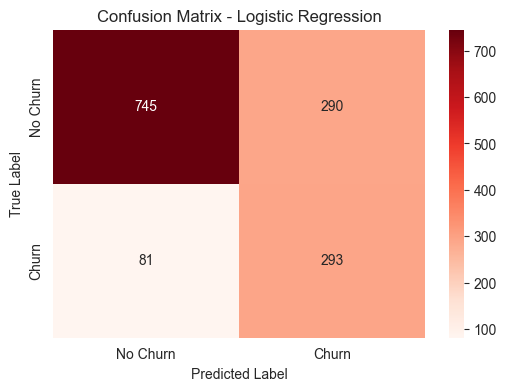


--- Training and Evaluating: Random Forest ---
Training Accuracy: 0.9975
Test Accuracy: 0.7814
ROC AUC Score: 0.8196

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



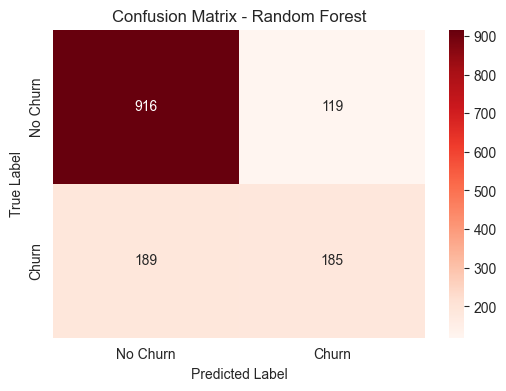


--- Training and Evaluating: Support Vector Machine ---
Training Accuracy: 0.7703
Test Accuracy: 0.7452
ROC AUC Score: 0.8195

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



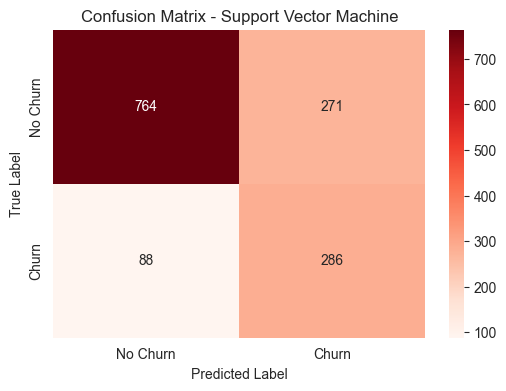


--- Training and Evaluating: XGBoost ---
Training Accuracy: 0.9240
Test Accuracy: 0.7622
ROC AUC Score: 0.8137

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1035
           1       0.54      0.66      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



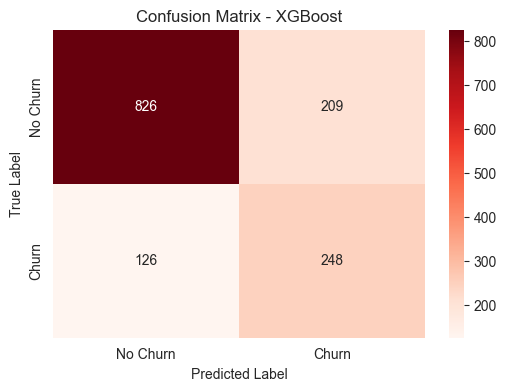

In [5]:
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear", class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=42
    ),
    "Support Vector Machine": SVC(
        probability=True, class_weight="balanced", random_state=42
    ),  # probability=True for ROC AUC
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight_val,
        random_state=42,
    ),
}

results = {}
fitted_pipelines = {}  # Store fitted pipelines

for model_name, model in models.items():
    print(f"\n--- Training and Evaluating: {model_name} ---")

    # Create the full pipeline: preprocessor + model
    pipeline = Pipeline(
        [("preprocessor", preprocessor), ("classifier", model)]
    )

    # Train the model
    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline  # Store the fitted pipeline

    # Make predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    y_proba_test = pipeline.predict_proba(X_test)[
        :, 1
    ]  # Probabilities for ROC AUC

    # Evaluate
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    roc_auc = roc_auc_score(y_test, y_proba_test)

    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")

    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Reds",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    results[model_name] = {
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "ROC AUC": roc_auc,
        "Classification Report": classification_report(
            y_test, y_pred_test, output_dict=True
        ),
        "Confusion Matrix": cm,
    }

## 6. Model Comparison
Summarize the performance metrics for all models.

In [6]:
comparison_df = pd.DataFrame(
    [
        (
            model,
            data["Test Accuracy"],
            data["ROC AUC"],
            data["Classification Report"]["1"]["f1-score"],
            data["Classification Report"]["1"][
                "precision"
            ],  # New precision column
            data["Classification Report"]["1"]["recall"],
        )
        for model, data in results.items()
    ],
    columns=[
        "Model",
        "Test Accuracy",
        "ROC AUC",
        "F1-score (Churn=1)",
        "Precision (Churn=1)",  # New precision column
        "Recall (Churn=1)",
    ],
).sort_values(by="ROC AUC", ascending=False)
display(comparison_df)


,Model,Test Accuracy,ROC AUC,F1-score (Churn=1),Precision (Churn=1),Recall (Churn=1)
0,Logistic Regression,0.736693,0.841833,0.612330,0.502573,0.783422
1,Random Forest,0.781405,0.819569,0.545723,0.608553,0.494652
2,Support Vector Machine,0.745209,0.819497,0.614393,0.513465,0.764706
3,XGBoost,0.762243,0.813661,0.596871,0.542670,0.663102


## 7. Feature Importance Analysis

This section analyzes the feature importances from one of the trained models to understand which factors most influence churn prediction.


--- Feature Importance Analysis (Logistic Regression) ---


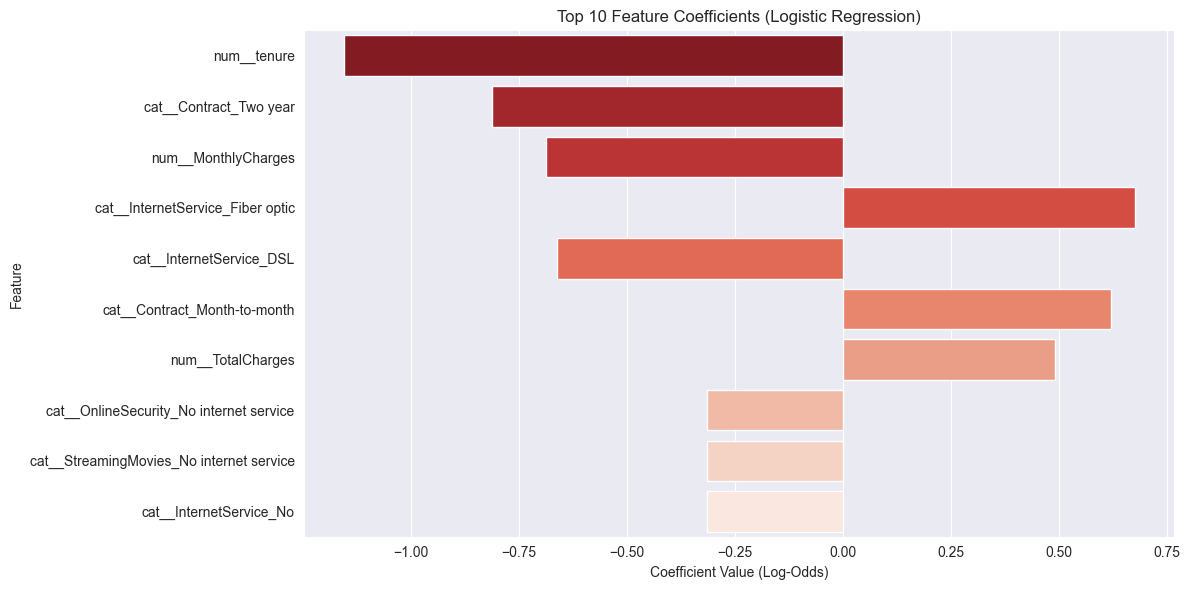


Top N features by absolute coefficient value:


,feature,coefficient
3,num__tenure,-1.154105
34,cat__Contract_Two year,-0.812101
6,num__MonthlyCharges,-0.687560
12,cat__InternetService_Fiber optic,0.674709
11,cat__InternetService_DSL,-0.661915
32,cat__Contract_Month-to-month,0.619643
7,num__TotalCharges,0.489665
15,cat__OnlineSecurity_No internet service,-0.314559
30,cat__StreamingMovies_No internet service,-0.314559
13,cat__InternetService_No,-0.314559


In [7]:
chosen_model_for_importance = (
    "Logistic Regression"  # 'XGBoost', 'Random Forest'
)

print(f"\n--- Feature Importance Analysis ({chosen_model_for_importance}) ---")

model_pipeline = fitted_pipelines[chosen_model_for_importance]
trained_preprocessor = model_pipeline.named_steps["preprocessor"]
trained_model = model_pipeline.named_steps["classifier"]
feature_names = trained_preprocessor.get_feature_names_out()

# how many to plot
N = 10

if hasattr(trained_model, "feature_importances_"):
    importances = trained_model.feature_importances_
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    )
    importance_df = importance_df.sort_values(by="importance", ascending=False)

    plt.figure(figsize=(12, max(6, N * 0.4)))  # height fix
    sns.barplot(
        x="importance", y="feature", data=importance_df.head(N), palette="Reds"
    )
    plt.title(f"Top {N} Feature Importances ({chosen_model_for_importance})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("\nTop N features and their importances:")
    display(importance_df.head(N))

elif hasattr(
    trained_model, "coef_"
):  # For linear models like Logistic Regression
    coefficients = trained_model.coef_[0]
    importance_df = pd.DataFrame(
        {"feature": feature_names, "coefficient": coefficients}
    )
    importance_df["abs_coefficient"] = np.abs(importance_df["coefficient"])
    importance_df = importance_df.sort_values(
        by="abs_coefficient", ascending=False
    )

    plt.figure(figsize=(12, max(6, N * 0.4)))
    sns.barplot(
        x="coefficient",
        y="feature",
        data=importance_df.head(N),
        palette="Reds_r",
    )
    plt.title(f"Top {N} Feature Coefficients ({chosen_model_for_importance})")
    plt.xlabel("Coefficient Value (Log-Odds)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print("\nTop N features by absolute coefficient value:")
    display(importance_df[["feature", "coefficient"]].head(N))

## 8. Model Recommendation

Based on the evaluation results and the business use case (identifying at-risk customers for targeted retention campaigns), **Logistic Regression** is the recommended model for production.

## 9. Save Model for API Deployment

In [8]:
import joblib
import os

MODEL_NAME = "Logistic Regression"
MODEL_PATH = "churn_model.pkl"


# Save the full pipeline (preprocessor + classifier)
joblib.dump(fitted_pipelines[MODEL_NAME], MODEL_PATH)
print(f"Model '{MODEL_NAME}' saved to: {os.path.abspath(MODEL_PATH)}")

# Verify it loads correctly
loaded_model = joblib.load(MODEL_PATH)
sample_pred = loaded_model.predict(X_test.iloc[:3])
print(f"Verification — sample predictions from loaded model: {sample_pred}")


Model 'Logistic Regression' saved to: /Users/michel.zuidema/Documents/Code/Interviews/Data/interview-case-files/churn_model.pkl
Verification — sample predictions from loaded model: [0 1 0]
